# Analisis Data Kesehatan Nasional 2010-2024
### Kementerian Kesehatan Republik Indonesia

---
**Tujuan:** Memproses dan menganalisis data kesehatan untuk mendukung pengambilan kebijakan nasional.

## Import Library & Load Data

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Load data mentah
df = pd.read_excel('data/Dataset_kesehatan.xlsx')
print(f"Dataset loaded: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nKolom: {list(df.columns)}")
df.head()

Dataset loaded: 180 baris x 11 kolom

Kolom: ['Tahun', 'Provinsi', 'AHH', 'Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi', 'Tenaga_Medis', 'Rumah_Sakit', 'Imunisasi', 'Angka_Kematian', 'Penduduk']


,Tahun,Provinsi,AHH,Kasus_ISPA,Kasus_Diabetes,Kasus_Hipertensi,Tenaga_Medis,Rumah_Sakit,Imunisasi,Angka_Kematian,Penduduk
0,2010,DKI Jakarta,NaN,33465,14756,10840,2693,94,82.8,8.1,35834672
1,2010,Jawa Barat,73.2,21943,10107,28177,13072,73,63.7,14.3,35237299
2,2010,Jawa Tengah,64.3,28529,6833,18620,5909,354,95.9,15.5,28882879
3,2010,DI Yogyakarta,70.4,38870,15426,22071,7026,45,97.0,10.8,5273180
4,2010,Jawa Timur,64.4,37586,19456,9897,7364,131,NaN,5.9,36660235


---
# A.1 - Audit Data & Asesmen Kualitas

## A.1.a - Identifikasi Masalah Data

### i. Missing Values

=== MISSING VALUES ===
           Jumlah_Missing  Persentase (%)
AHH                    22            12.2
Imunisasi              20            11.1


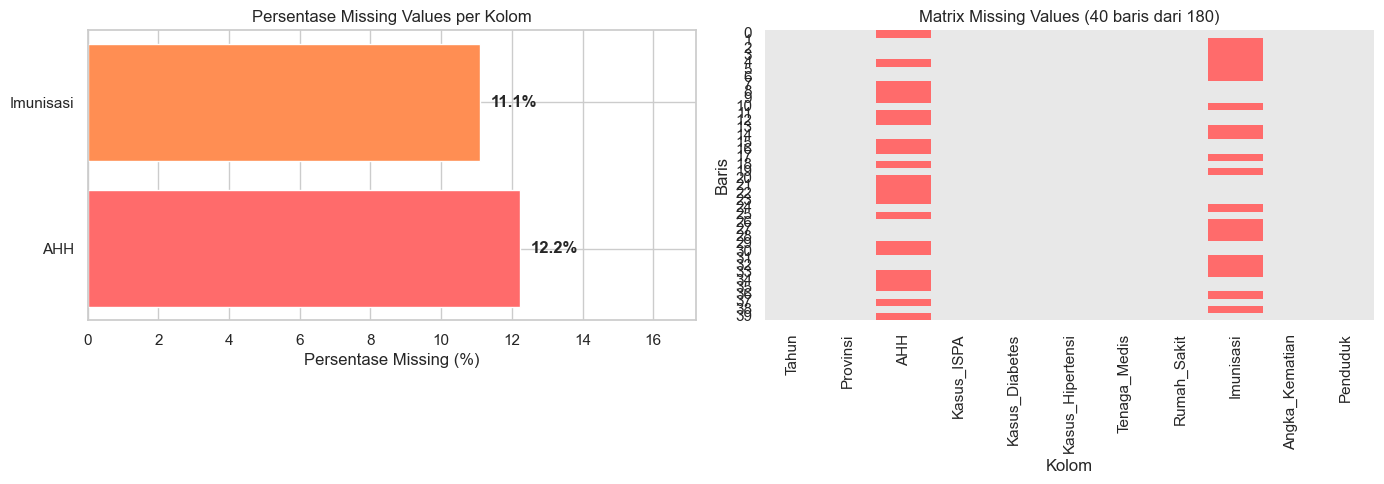


Detail baris dengan missing values:

--- AHH (22 missing) ---
 Tahun         Provinsi  AHH
  2010      DKI Jakarta  NaN
  2012      DKI Jakarta  NaN
  2013       Jawa Barat  NaN
  2013      Jawa Tengah  NaN
  2013            Papua  NaN
  2014            Papua  NaN
  2016    DI Yogyakarta  NaN
  2018 Sulawesi Selatan  NaN
  2018            Papua  NaN
  2019       Jawa Barat  NaN
  2019 Sulawesi Selatan  NaN
  2020       Jawa Barat  NaN
  2020      Jawa Tengah  NaN
  2020       Jawa Timur  NaN
  2020   Sumatera Barat  NaN
  2021   Sumatera Utara  NaN
  2021   Sumatera Barat  NaN
  2022       Jawa Barat  NaN
  2022      Jawa Tengah  NaN
  2022             Riau  NaN
  2022            Papua  NaN
  2024             Bali  NaN

--- Imunisasi (20 missing) ---
 Tahun         Provinsi  Imunisasi
  2010       Jawa Timur        NaN
  2011             Riau        NaN
  2011            Papua        NaN
  2012      DKI Jakarta        NaN
  2012   Sumatera Utara        NaN
  2012             Riau     

In [152]:
# Cek missing values
missing = pd.DataFrame({
    'Jumlah_Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(1)
})
missing = missing[missing['Jumlah_Missing'] > 0]

print("=== MISSING VALUES ===")
print(missing)

# Visualisasi 1: Bar chart persentase missing per kolom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cols_with_missing = df.columns[df.isnull().sum() > 0]
missing_pct = df[cols_with_missing].isnull().mean() * 100
bars = axes[0].barh(cols_with_missing, missing_pct, color=['#FF6B6B', '#FF8E53'])
axes[0].set_xlabel('Persentase Missing (%)')
axes[0].set_title('Persentase Missing Values per Kolom')
axes[0].set_xlim(0, max(missing_pct) + 5)
for bar, pct in zip(bars, missing_pct):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontweight='bold')

# Visualisasi 2: Matrix plot - hanya tampilkan baris yang punya missing
df_missing_rows = df[df.isnull().any(axis=1)].copy()
df_missing_rows = df_missing_rows.reset_index(drop=True)
sns.heatmap(df_missing_rows.isnull(), cbar=False, ax=axes[1],
            cmap=['#E8E8E8', '#FF6B6B'], yticklabels=True, xticklabels=True)
axes[1].set_title(f'Matrix Missing Values ({len(df_missing_rows)} baris dari {len(df)})')
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Baris')

plt.tight_layout()
plt.show()

# Detail baris yang missing
print("\nDetail baris dengan missing values:")
for col in missing.index:
    print(f"\n--- {col} ({missing.loc[col, 'Jumlah_Missing']} missing) ---")
    print(df[df[col].isnull()][['Tahun', 'Provinsi', col]].to_string(index=False))

### ii. Outlier

=== OUTLIER (Metode IQR) ===

Kasus_ISPA: 4 outlier | Range normal: [-5817, 68450]
    Kalimantan Timur (2015): 126405
    Sumatera Barat (2017): 104250
    Riau (2017): 118296
    Jawa Timur (2023): 113178

Ringkasan outlier:
     Kolom  Jumlah_Outlier  Batas_Bawah  Batas_Atas
Kasus_ISPA               4      -5817.1     68449.9


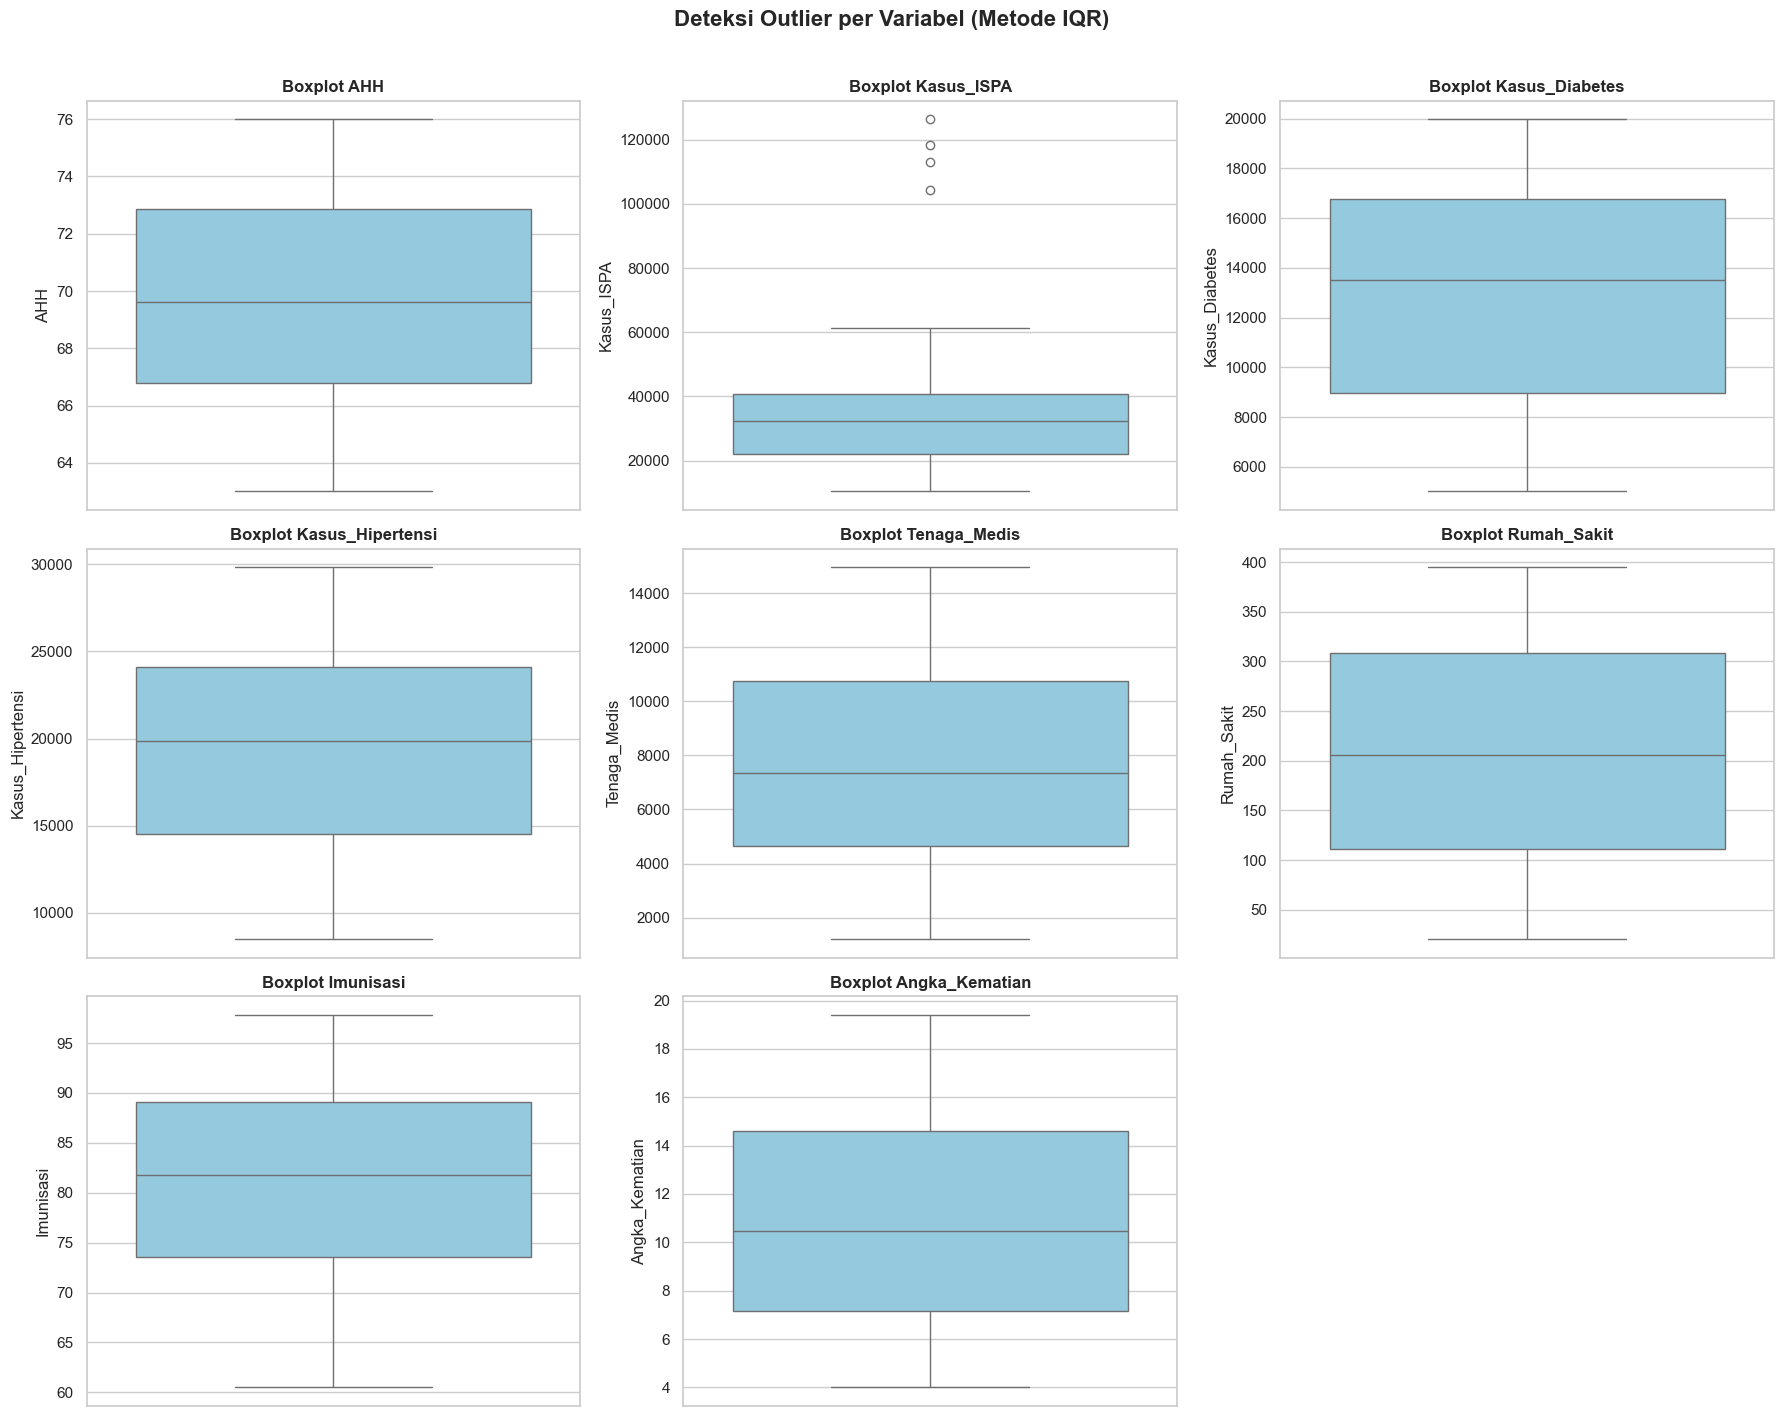

In [153]:
def detect_outliers_iqr(series):
    """Mengembalikan list outlier dan batas IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

# Analisis outlier: SEMUA kolom numerik KECUALI Tahun dan Penduduk
# Penduduk tidak di-check sebagai outlier karena perbedaan ukuran populasi antar provinsi memang wajar
cols_outlier = [col for col in df.select_dtypes(include='number').columns
                if col not in ['Tahun', 'Penduduk']]

print("=== OUTLIER (Metode IQR) ===")
outlier_report = []
for col in cols_outlier:
    outliers, lower, upper = detect_outliers_iqr(df[col])
    if len(outliers) > 0:
        outlier_report.append({
            'Kolom': col,
            'Jumlah_Outlier': len(outliers),
            'Batas_Bawah': round(lower, 1),
            'Batas_Atas': round(upper, 1)
        })
        print(f"\n{col}: {len(outliers)} outlier | Range normal: [{lower:.0f}, {upper:.0f}]")
        for idx in outliers.index:
            print(f"    {df.loc[idx, 'Provinsi']} ({df.loc[idx, 'Tahun']}): {outliers[idx]}")

if outlier_report:
    print("\nRingkasan outlier:")
    print(pd.DataFrame(outlier_report).to_string(index=False))
else:
    print("\nTidak ditemukan outlier signifikan.")

# Visualisasi boxplot
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cols_outlier):
    if i < len(axes):
        sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Boxplot {col}', fontweight='bold')
for i in range(len(cols_outlier), len(axes)):
    axes[i].set_visible(False)
fig.suptitle('Deteksi Outlier per Variabel (Metode IQR)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### iii. Inkonsistensi Data

In [154]:
# Cek duplikasi
duplikat = df.duplicated(subset=['Tahun', 'Provinsi']).sum()
print(f"Duplikasi (Tahun + Provinsi): {duplikat} baris")

# Cek konsistensi nama provinsi
print(f"\nJumlah provinsi unik: {df['Provinsi'].nunique()}")
print(f"Daftar: {sorted(df['Provinsi'].unique())}")

# Cek distribusi data per tahun
print("\nDistribusi data per tahun:")
print(df['Tahun'].value_counts().sort_index().to_string())

# Cek nilai negatif
numeric_all = df.select_dtypes(include='number').columns.drop('Tahun')
print("\nCek nilai negatif:")
for col in numeric_all:
    neg = (df[col] < 0).sum()
    status = f"Terdeteksi {neg} nilai negatif" if neg > 0 else "Tidak ada"
    print(f"  {col}: {status}")

# Cek logika bisnis
print("\nCek logika bisnis:")
if 'AHH' in df.columns:
    invalid = df[(df['AHH'] < 0) | (df['AHH'] > 100)].shape[0]
    print(f"  AHH (range 0-100): {'Terdeteksi ' + str(invalid) + ' nilai tidak valid' if invalid else 'Semua valid'}")
if 'Imunisasi' in df.columns:
    invalid = df[(df['Imunisasi'] < 0) | (df['Imunisasi'] > 100)].shape[0]
    print(f"  Imunisasi (range 0-100%): {'Terdeteksi ' + str(invalid) + ' nilai tidak valid' if invalid else 'Semua valid'}")

# Cek satuan Angka_Kematian
print("\nCek satuan Angka_Kematian:")
print(f"  Range: {df['Angka_Kematian'].min():.1f} - {df['Angka_Kematian'].max():.1f}")
print(f"  Median: {df['Angka_Kematian'].median():.1f}")
print("  Catatan: Angka Kematian dalam dataset ini tampaknya dalam satuan 'per 1.000 penduduk'")
print("  (bukan per 100.000), berdasarkan range nilai 5-15 yang umum untuk crude death rate.")

print("\nCatatan: Anomali data akan dibahas lebih mendalam di bagian A.3.e")

Duplikasi (Tahun + Provinsi): 0 baris

Jumlah provinsi unik: 12
Daftar: ['Bali', 'DI Yogyakarta', 'DKI Jakarta', 'Jawa Barat', 'Jawa Tengah', 'Jawa Timur', 'Kalimantan Timur', 'Papua', 'Riau', 'Sulawesi Selatan', 'Sumatera Barat', 'Sumatera Utara']

Distribusi data per tahun:
Tahun
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12

Cek nilai negatif:
  AHH: Tidak ada
  Kasus_ISPA: Tidak ada
  Kasus_Diabetes: Tidak ada
  Kasus_Hipertensi: Tidak ada
  Tenaga_Medis: Tidak ada
  Rumah_Sakit: Tidak ada
  Imunisasi: Tidak ada
  Angka_Kematian: Tidak ada
  Penduduk: Tidak ada

Cek logika bisnis:
  AHH (range 0-100): Semua valid
  Imunisasi (range 0-100%): Semua valid

Cek satuan Angka_Kematian:
  Range: 4.0 - 19.4
  Median: 10.4
  Catatan: Angka Kematian dalam dataset ini tampaknya dalam satuan 'per 1.000 penduduk'
  (bukan per 100.000), berdasarkan range nilai 5-15 yang umum unt

### A.1.b - Dampak & Strategi Penanganan

| Masalah | Dampak terhadap Analisis | Strategi Penanganan |
|---------|-------------------------|---------------------|
| **Missing Values (AHH: 22, Imunisasi: 20)** | Menurunkan akurasi tren dan korelasi, mengurangi jumlah sampel analisis | Imputasi **median per provinsi** - robust terhadap outlier |
| **Outlier** (ISPA, Diabetes, Hipertensi, dll) | Distorsi pada mean, standar deviasi, model regresi, dan visualisasi | **Winsorization** (IQR 1.5x) - batasi nilai ekstrem, data asli tetap tersimpan |
| **Inkonsistensi** | Tidak ditemukan duplikasi atau nilai di luar batas logis | Tidak perlu penanganan khusus |
| **Satuan tidak jelas (Angka_Kematian)** | Sulit membandingkan dengan standar nasional | Diasumsikan per 1.000 penduduk berdasarkan range nilai |

**Alasan Pemilihan Strategi:**
1. **Median** lebih robust daripada mean karena tidak terpengaruh outlier.
2. **Winsorization** dipilih daripada menghapus data - outlier bisa valid (misal saat wabah) dan penting untuk analisis kebijakan.
3. **Penduduk tidak di-winsorize** karena perbedaan ukuran populasi antar provinsi memang wajar dan bukan outlier sejati.

---
# A.2 - Strategi Data Cleaning

### A.2.a - Teknik Imputasi (Median per Provinsi)

In [155]:
# Buat salinan data untuk cleaning
df_clean = df.copy()

# --- Imputasi AHH ---
print("=== IMPUTASI AHH ===")
print(f"Missing sebelum: {df_clean['AHH'].isnull().sum()}")

median_nasional_ahh = df_clean['AHH'].median()
df_clean['AHH'] = df_clean.groupby('Provinsi')['AHH'].transform(
    lambda x: x.fillna(x.median() if not pd.isna(x.median()) else median_nasional_ahh)
)
df_clean['AHH'] = df_clean['AHH'].fillna(median_nasional_ahh)
print(f"Missing sesudah: {df_clean['AHH'].isnull().sum()}")

# --- Imputasi Imunisasi ---
print("\n=== IMPUTASI IMUNISASI ===")
print(f"Missing sebelum: {df_clean['Imunisasi'].isnull().sum()}")

median_nasional_imun = df_clean['Imunisasi'].median()
df_clean['Imunisasi'] = df_clean.groupby('Provinsi')['Imunisasi'].transform(
    lambda x: x.fillna(x.median() if not pd.isna(x.median()) else median_nasional_imun)
)
df_clean['Imunisasi'] = df_clean['Imunisasi'].fillna(median_nasional_imun)
print(f"Missing sesudah: {df_clean['Imunisasi'].isnull().sum()}")

print("\nImputasi selesai!")

=== IMPUTASI AHH ===
Missing sebelum: 22
Missing sesudah: 0

=== IMPUTASI IMUNISASI ===
Missing sebelum: 20
Missing sesudah: 0

Imputasi selesai!


### A.2.b - Penanganan Outlier (Winsorization)

**Catatan penting:** Winsorization dilakukan SETELAH imputasi agar:
- Nilai yang diimputasi (median) tidak ikut terpotong oleh batas IQR
- Median per provinsi biasanya sudah berada di tengah distribusi, sehingga aman dari clipping

In [156]:
def winsorize_iqr(series, factor=1.5):
    """Winsorize: nilai di luar [Q1 - factor*IQR, Q3 + factor*IQR] dibatasi."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper), lower, upper

# Kolom yang di-winsorize: SEMUA numerik KECUALI Tahun dan Penduduk
# Penduduk tidak di-winsorize karena perbedaan populasi antar provinsi memang wajar
cols_winsorize = [col for col in df_clean.select_dtypes(include='number').columns
                  if col not in ['Tahun', 'Penduduk']]

print("=== WINSORIZATION ===")
for col in cols_winsorize:
    df_clean[col], lower, upper = winsorize_iqr(df_clean[col])
    print(f"{col:20s} - dibatasi ke [{lower:,.0f}, {upper:,.0f}]")

print("\nWinsorization selesai!")
print(f"Catatan: Kolom 'Penduduk' TIDAK di-winsorize karena ukuran populasi antar provinsi memang bervariasi.")

=== WINSORIZATION ===
AHH                  - dibatasi ke [59, 80]
Kasus_ISPA           - dibatasi ke [-5,817, 68,450]
Kasus_Diabetes       - dibatasi ke [-2,755, 28,455]
Kasus_Hipertensi     - dibatasi ke [228, 38,401]
Tenaga_Medis         - dibatasi ke [-4,529, 19,908]
Rumah_Sakit          - dibatasi ke [-185, 605]
Imunisasi            - dibatasi ke [52, 111]
Angka_Kematian       - dibatasi ke [-4, 26]

Winsorization selesai!
Catatan: Kolom 'Penduduk' TIDAK di-winsorize karena ukuran populasi antar provinsi memang bervariasi.


### A.2.c - Normalisasi

In [157]:
# 3 teknik normalisasi
def min_max(s):
    """Min-Max ke range [0, 1]."""
    return (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else s * 0

def z_score(s):
    """Z-Score: mean=0, std=1."""
    return (s - s.mean()) / s.std()

def log_transform(s):
    """Log(x+1) untuk mengurangi skewness."""
    return np.log1p(s)

print("=== NORMALISASI ===")
df_norm = df_clean.copy()
cols_norm = [col for col in df_clean.select_dtypes(include='number').columns if col != 'Tahun']

for col in cols_norm:
    df_norm[f'{col}_minmax'] = min_max(df_clean[col])
    df_norm[f'{col}_zscore'] = z_score(df_clean[col])
    df_norm[f'{col}_log']    = log_transform(df_clean[col])

print(f"Kolom yang dinormalisasi: {list(cols_norm)}")
print("Teknik: Min-Max [0,1], Z-Score, Log Transform")
print("\nNormalisasi selesai!")
print("\nCatatan: df_clean digunakan untuk analisis deskriptif (A.3).")
print("df_norm disediakan untuk kebutuhan modeling atau machine learning di tahap selanjutnya.")

# Contoh hasil
cols_display = ['Tahun', 'Provinsi'] + list(cols_norm[:3]) + [f'{c}_minmax' for c in cols_norm[:3]]
df_norm[cols_display].head()

=== NORMALISASI ===
Kolom yang dinormalisasi: ['AHH', 'Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi', 'Tenaga_Medis', 'Rumah_Sakit', 'Imunisasi', 'Angka_Kematian', 'Penduduk']
Teknik: Min-Max [0,1], Z-Score, Log Transform

Normalisasi selesai!

Catatan: df_clean digunakan untuk analisis deskriptif (A.3).
df_norm disediakan untuk kebutuhan modeling atau machine learning di tahap selanjutnya.


,Tahun,Provinsi,AHH,Kasus_ISPA,Kasus_Diabetes,AHH_minmax,Kasus_ISPA_minmax,Kasus_Diabetes_minmax
0,2010,DKI Jakarta,68.1,33465.0,14756,0.392308,0.397766,0.651149
1,2010,Jawa Barat,73.2,21943.0,10107,0.784615,0.199425,0.340636
2,2010,Jawa Tengah,64.3,28529.0,6833,0.100000,0.312798,0.121961
3,2010,DI Yogyakarta,70.4,38870.0,15426,0.569231,0.490809,0.695899
4,2010,Jawa Timur,64.4,37586.0,19456,0.107692,0.468706,0.965068


### Simpan Data Hasil Pemrosesan

In [158]:
# Simpan ke folder data/
df_clean.to_excel('data/Dataset_kesehatan_cleaned.xlsx', index=False)
df_norm.to_excel('data/Dataset_kesehatan_normalized.xlsx', index=False)
print("Data tersimpan di folder data/")
print(f"  - Dataset_kesehatan_cleaned.xlsx   ({df_clean.shape[0]} baris, {df_clean.shape[1]} kolom)")
print(f"  - Dataset_kesehatan_normalized.xlsx  ({df_norm.shape[0]} baris, {df_norm.shape[1]} kolom)")

Data tersimpan di folder data/
  - Dataset_kesehatan_cleaned.xlsx   (180 baris, 11 kolom)
  - Dataset_kesehatan_normalized.xlsx  (180 baris, 38 kolom)


---
# A.3 - Analisis Deskriptif Mendalam

## A.3.a - Apakah Peningkatan Tenaga Medis Selalu Menurunkan Angka Kematian?

=== KORELASI GLOBAL ===
Korelasi (Tenaga Medis vs Angka Kematian): -0.079


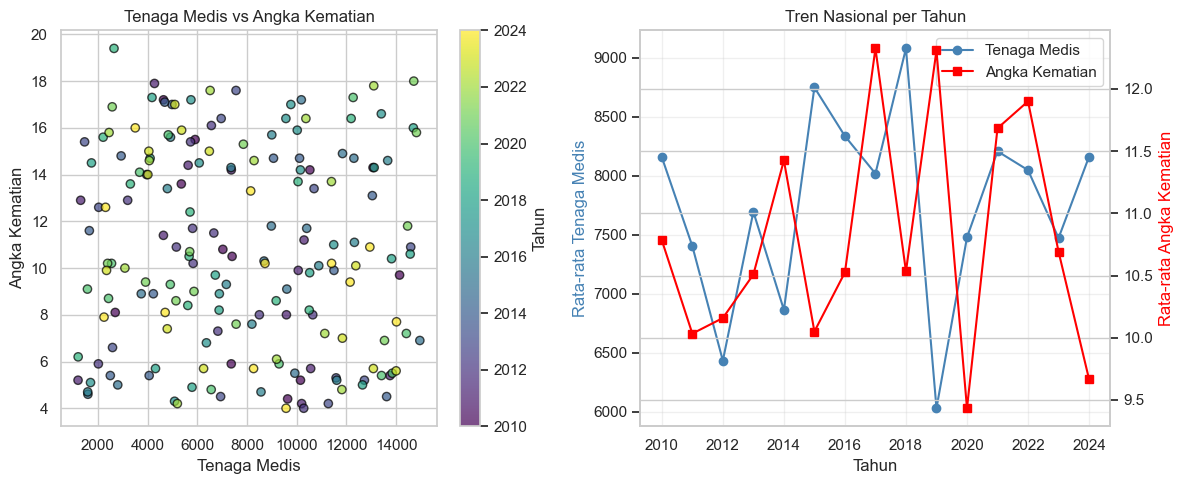


=== ANALISIS PER PROVINSI ===
Mencari provinsi di mana Tenaga Medis naik TAPI Angka Kematian juga naik...

Ditemukan 37 observasi di mana Tenaga Medis naik TAPI Angka Kematian juga naik:
     Provinsi  Tahun  Tenaga_Medis  Delta_Medis  Angka_Kematian  Delta_Kematian
  DKI Jakarta   2014        4979.0       2395.0            17.0            10.4
  DKI Jakarta   2021       14464.0       1050.0            11.8             6.4
   Jawa Barat   2012        8496.0       7300.0             8.0             2.8
  Jawa Tengah   2012        5726.0         98.0            15.4             1.0
  Jawa Tengah   2016       13662.0      10867.0            14.6             9.6
  Jawa Tengah   2021       14819.0        973.0            15.8            10.3
DI Yogyakarta   2013        3957.0        763.0            14.0             1.1
DI Yogyakarta   2018       12648.0       7566.0             5.0             0.7
   Jawa Timur   2011        9585.0       2221.0             8.0             2.1
   Jawa Timu

In [159]:
# --- Analisis Korelasi Global ---
corr = df_clean['Tenaga_Medis'].corr(df_clean['Angka_Kematian'])
print("=== KORELASI GLOBAL ===")
print(f"Korelasi (Tenaga Medis vs Angka Kematian): {corr:.3f}")

plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(df_clean['Tenaga_Medis'], df_clean['Angka_Kematian'],
            c=df_clean['Tahun'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.colorbar(label='Tahun')
plt.xlabel('Tenaga Medis')
plt.ylabel('Angka Kematian')
plt.title('Tenaga Medis vs Angka Kematian')

# Tren per tahun (rata-rata nasional)
plt.subplot(1, 2, 2)
trend = df_clean.groupby('Tahun')[['Tenaga_Medis', 'Angka_Kematian']].mean()
years = trend.index
ax1 = plt.gca()
line1 = ax1.plot(years, trend['Tenaga_Medis'], marker='o', color='steelblue')
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Rata-rata Tenaga Medis', color='steelblue')
ax2 = ax1.twinx()
line2 = ax2.plot(years, trend['Angka_Kematian'], marker='s', color='red')
ax2.set_ylabel('Rata-rata Angka Kematian', color='red')
plt.title('Tren Nasional per Tahun')
# Buat legend manual agar tidak duplikat
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', marker='o', label='Tenaga Medis'),
    Line2D([0], [0], color='red', marker='s', label='Angka Kematian')
]
ax1.legend(handles=legend_elements, loc='best')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Analisis Per Provinsi: Apakah selalu menurun? ---
print("\n=== ANALISIS PER PROVINSI ===")
print("Mencari provinsi di mana Tenaga Medis naik TAPI Angka Kematian juga naik...\n")

prov_trend = df_clean.groupby(['Provinsi', 'Tahun'])[['Tenaga_Medis', 'Angka_Kematian']].mean().reset_index()

kontradiksi = []
for prov in df_clean['Provinsi'].unique():
    pdata = prov_trend[prov_trend['Provinsi'] == prov].sort_values('Tahun')
    if len(pdata) < 2:
        continue
    # Hitung perubahan dari tahun ke tahun
    pdata['Delta_Medis'] = pdata['Tenaga_Medis'].diff()
    pdata['Delta_Kematian'] = pdata['Angka_Kematian'].diff()
    # Cek: tenaga medis naik (delta > 0) tapi kematian juga naik (delta > 0)
    kontra_rows = pdata[(pdata['Delta_Medis'] > 0) & (pdata['Delta_Kematian'] > 0)]
    if len(kontra_rows) > 0:
        for _, row in kontra_rows.iterrows():
            kontradiksi.append({
                'Provinsi': prov,
                'Tahun': row['Tahun'],
                'Tenaga_Medis': row['Tenaga_Medis'],
                'Delta_Medis': row['Delta_Medis'],
                'Angka_Kematian': row['Angka_Kematian'],
                'Delta_Kematian': row['Delta_Kematian']
            })

if kontradiksi:
    print(f"Ditemukan {len(kontradiksi)} observasi di mana Tenaga Medis naik TAPI Angka Kematian juga naik:")
    print(pd.DataFrame(kontradiksi).head(15).to_string(index=False))
    print("\nKesimpulan: Peningkatan tenaga medis TIDAK SELALU menurunkan angka kematian.")
    print("Faktor lain (sanitasi, gizi, akses fasilitas, penyakit menular) juga berpengaruh.")
else:
    print("Tidak ditemukan kontradiksi signifikan.")
    print("Kesimpulan: Tren umum menunjukkan peningkatan tenaga medis berkorelasi dengan penurunan angka kematian.")

## A.3.b - Provinsi Mana yang "Tidak Efisien"?

=== PROVINSI TIDAK EFISIEN ===
(Tenaga Medis di atas median, tapi Angka Kematian juga di atas median)

Median Tenaga Medis: 7626
Median Angka Kematian: 11.1

Jumlah provinsi tidak efisien: 3 dari 12 provinsi

Daftar provinsi tidak efisien:
   Provinsi  Tenaga_Medis  Angka_Kematian
Jawa Tengah   9229.066667       12.753333
       Bali   8311.866667       11.540000
 Jawa Timur   7858.466667       11.100000


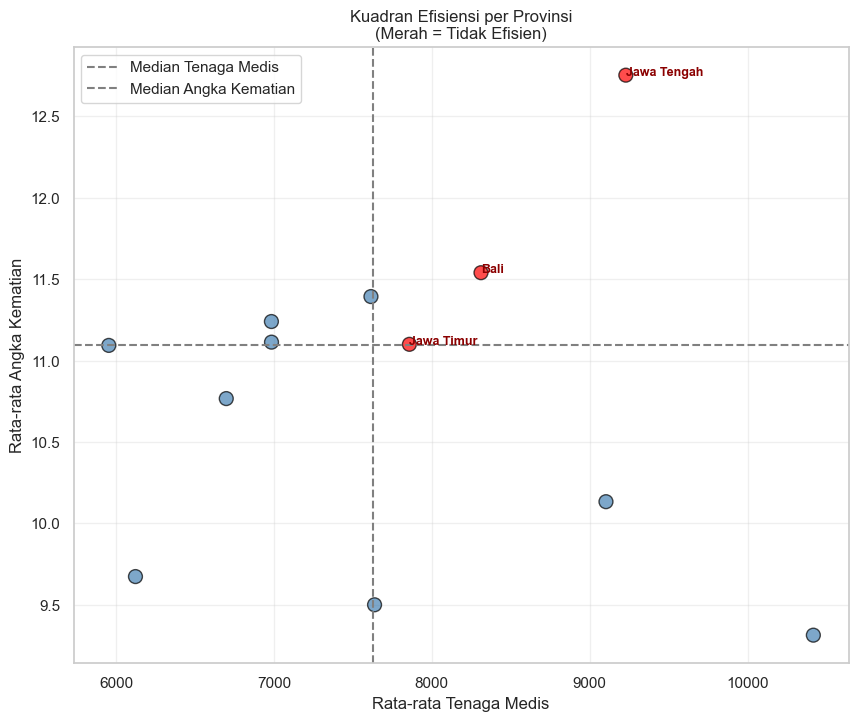


Provinsi EFISIEN (Tenaga Medis tinggi, Angka Kematian rendah):
      Provinsi  Tenaga_Medis  Angka_Kematian
    Jawa Barat   7637.733333        9.500000
         Papua  10416.733333        9.313333
Sumatera Utara   9103.400000       10.133333


In [160]:
# Agregasi rata-rata per provinsi terlebih dahulu
prov_avg = df_clean.groupby('Provinsi')[['Tenaga_Medis', 'Angka_Kematian']].mean().reset_index()

# Hitung median nasional dari rata-rata per provinsi
med_med = prov_avg['Tenaga_Medis'].median()
med_kemat = prov_avg['Angka_Kematian'].median()

# Tandai provinsi tidak efisien
prov_avg['Tidak_Efisien'] = (prov_avg['Tenaga_Medis'] > med_med) & (prov_avg['Angka_Kematian'] > med_kemat)

print("=== PROVINSI TIDAK EFISIEN ===")
print("(Tenaga Medis di atas median, tapi Angka Kematian juga di atas median)")
print(f"\nMedian Tenaga Medis: {med_med:.0f}")
print(f"Median Angka Kematian: {med_kemat:.1f}")

tidak_efisien = prov_avg[prov_avg['Tidak_Efisien']].sort_values('Angka_Kematian', ascending=False)
print(f"\nJumlah provinsi tidak efisien: {len(tidak_efisien)} dari {len(prov_avg)} provinsi")
print("\nDaftar provinsi tidak efisien:")
print(tidak_efisien[['Provinsi', 'Tenaga_Medis', 'Angka_Kematian']].to_string(index=False))

# Visualisasi kuadran
plt.figure(figsize=(10, 8))
plt.axvline(med_med, color='gray', linestyle='--', label='Median Tenaga Medis')
plt.axhline(med_kemat, color='gray', linestyle='--', label='Median Angka Kematian')

# Warna berdasarkan efisiensi
colors = prov_avg['Tidak_Efisien'].map({True: 'red', False: 'steelblue'})
plt.scatter(prov_avg['Tenaga_Medis'], prov_avg['Angka_Kematian'],
            c=colors, s=100, alpha=0.7, edgecolors='black')

# Label provinsi yang tidak efisien
for _, row in tidak_efisien.iterrows():
    plt.annotate(row['Provinsi'], (row['Tenaga_Medis'], row['Angka_Kematian']),
                fontsize=9, fontweight='bold', color='darkred')

plt.xlabel('Rata-rata Tenaga Medis')
plt.ylabel('Rata-rata Angka Kematian')
plt.title('Kuadran Efisiensi per Provinsi\n(Merah = Tidak Efisien)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Provinsi efisien (tenaga medis tinggi, kematian rendah)
efisien = prov_avg[(prov_avg['Tenaga_Medis'] > med_med) & (prov_avg['Angka_Kematian'] <= med_kemat)]
print("\nProvinsi EFISIEN (Tenaga Medis tinggi, Angka Kematian rendah):")
if len(efisien) > 0:
    print(efisien[['Provinsi', 'Tenaga_Medis', 'Angka_Kematian']].to_string(index=False))
else:
    print("Tidak ada provinsi yang memenuhi kriteria ini.")

## A.3.c - Penyakit Mana yang Paling Berkontribusi terhadap Kematian?

=== KETERBATASAN DATA ===
Dataset hanya memiliki 3 jenis penyakit: Kasus_ISPA, Kasus_Diabetes, Kasus_Hipertensi
Data penyakit lain (jantung, kanker, stroke, dll) tidak tersedia dalam dataset ini.
Oleh karena itu, analisis kontribusi penyakit terhadap kematian terbatas pada 3 penyakit ini.

=== KORELASI PENYAKIT vs ANGKA KEMATIAN ===
  Kasus_ISPA          : -0.013
  Kasus_Hipertensi    : -0.031
  Kasus_Diabetes      : -0.038


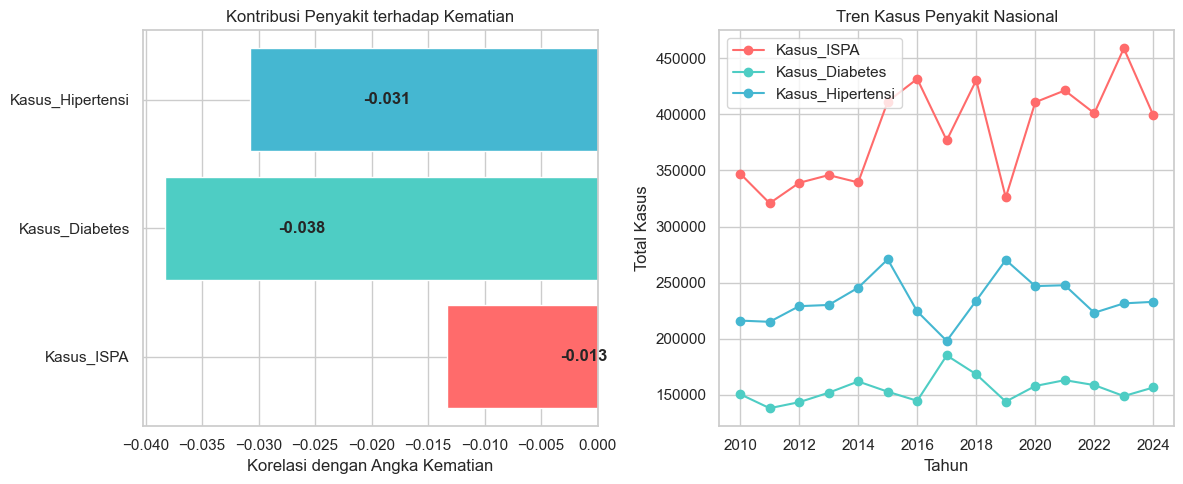


Penyakit paling berkontribusi (dari 3 yang tersedia): Kasus_ISPA (korelasi = -0.013)
Catatan: Korelasi yang rendah menunjukkan bahwa hubungan penyakit-kematian bersifat tidak langsung.
Faktor lain seperti akses layanan kesehatan, usia, dan komorbiditas juga berperan.


In [161]:
# Korelasi masing-masing penyakit dengan angka kematian
penyakit = ['Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi']
print("=== KETERBATASAN DATA ===")
print(f"Dataset hanya memiliki 3 jenis penyakit: {', '.join(penyakit)}")
print("Data penyakit lain (jantung, kanker, stroke, dll) tidak tersedia dalam dataset ini.")
print("Oleh karena itu, analisis kontribusi penyakit terhadap kematian terbatas pada 3 penyakit ini.\n")

korl = {p: df_clean[p].corr(df_clean['Angka_Kematian']) for p in penyakit}

print("=== KORELASI PENYAKIT vs ANGKA KEMATIAN ===")
for p, r in sorted(korl.items(), key=lambda x: x[1], reverse=True):
    print(f"  {p:20s}: {r:.3f}")

# Visualisasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.barh(list(korl.keys()), list(korl.values()),
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xlabel('Korelasi dengan Angka Kematian')
plt.title('Kontribusi Penyakit terhadap Kematian')
for bar, val in zip(bars, korl.values()):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold')

plt.subplot(1, 2, 2)
for p, color in zip(penyakit, ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    plt.plot(df_clean.groupby('Tahun')[p].sum(), marker='o', label=p, color=color)
plt.xlabel('Tahun')
plt.ylabel('Total Kasus')
plt.title('Tren Kasus Penyakit Nasional')
plt.legend()

plt.tight_layout()
plt.show()

top = max(korl, key=korl.get)
print(f"\nPenyakit paling berkontribusi (dari 3 yang tersedia): {top} (korelasi = {korl[top]:.3f})")
print("Catatan: Korelasi yang rendah menunjukkan bahwa hubungan penyakit-kematian bersifat tidak langsung.")
print("Faktor lain seperti akses layanan kesehatan, usia, dan komorbiditas juga berperan.")

## A.3.d - Apakah Imunisasi Berpengaruh terhadap Peningkatan AHH?

Korelasi (Imunisasi vs AHH): 0.045


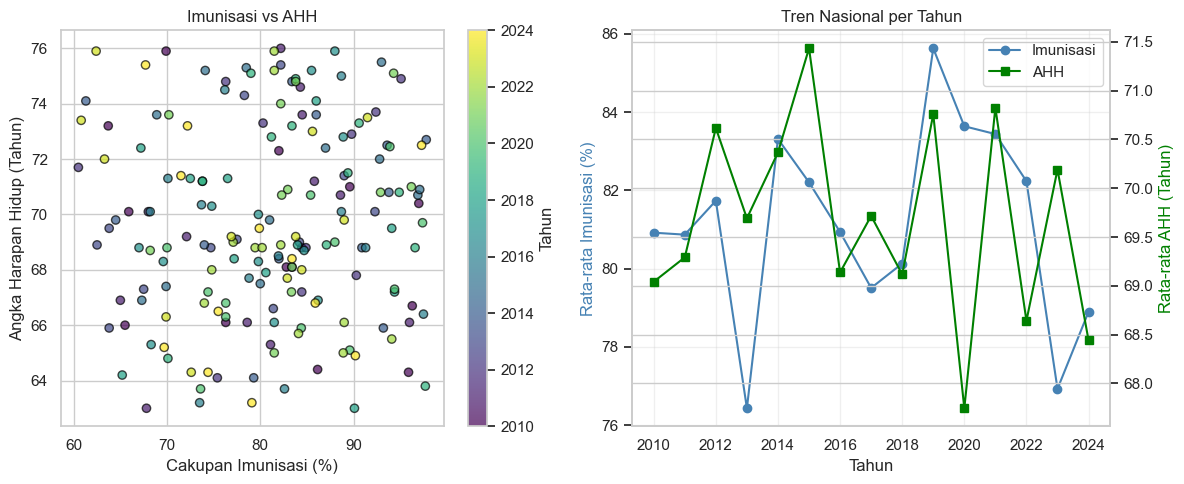


Korelasi positif lemah/sedang: ada pengaruh positif, namun ada faktor lain yang juga berperan.
Faktor seperti gizi, sanitasi, pendidikan, dan ekonomi juga memengaruhi AHH.


In [162]:
# Korelasi Imunisasi vs AHH
corr_imun_ahh = df_clean['Imunisasi'].corr(df_clean['AHH'])
print(f"Korelasi (Imunisasi vs AHH): {corr_imun_ahh:.3f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_clean['Imunisasi'], df_clean['AHH'],
            c=df_clean['Tahun'], cmap='viridis', alpha=0.7, edgecolors='black')
plt.colorbar(label='Tahun')
plt.xlabel('Cakupan Imunisasi (%)')
plt.ylabel('Angka Harapan Hidup (Tahun)')
plt.title('Imunisasi vs AHH')

# Tren nasional per tahun
plt.subplot(1, 2, 2)
trend = df_clean.groupby('Tahun')[['Imunisasi', 'AHH']].mean()
years = trend.index
ax1 = plt.gca()
ax1.plot(years, trend['Imunisasi'], marker='o', color='steelblue')
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Rata-rata Imunisasi (%)', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(years, trend['AHH'], marker='s', color='green')
ax2.set_ylabel('Rata-rata AHH (Tahun)', color='green')
plt.title('Tren Nasional per Tahun')
# Buat legend manual agar tidak duplikat
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', marker='o', label='Imunisasi'),
    Line2D([0], [0], color='green', marker='s', label='AHH')
]
ax1.legend(handles=legend_elements, loc='best')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if corr_imun_ahh > 0.5:
    print("\nKorelasi positif kuat: peningkatan cakupan imunisasi berkorelasi dengan peningkatan AHH.")
elif corr_imun_ahh > 0:
    print("\nKorelasi positif lemah/sedang: ada pengaruh positif, namun ada faktor lain yang juga berperan.")
    print("Faktor seperti gizi, sanitasi, pendidikan, dan ekonomi juga memengaruhi AHH.")
else:
    print("\nTidak ditemukan hubungan positif yang jelas antara imunisasi dan AHH dalam dataset ini.")

## A.3.e - Identifikasi Anomali Data

**Catatan:** Anomali diidentifikasi menggunakan **data mentah (df)** sebelum winsorization, karena setelah winsorization nilai ekstrem sudah dipotong (di-clip) sehingga anomali tidak lagi terlihat.

In [163]:
# ============================================================
# ANOMALI 1: Kasus ISPA Ekstrem (gunakan data RAW = df)
# ============================================================
print("=== ANOMALI 1: Kasus ISPA Ekstrem ===")
Q1 = df['Kasus_ISPA'].quantile(0.25)
Q3 = df['Kasus_ISPA'].quantile(0.75)
IQR = Q3 - Q1
top_ispa = df.loc[df['Kasus_ISPA'].idxmax()]
print(f"Provinsi : {top_ispa['Provinsi']}")
print(f"Tahun    : {top_ispa['Tahun']}")
print(f"Kasus    : {top_ispa['Kasus_ISPA']:,.0f}")
print(f"Batas IQR: [{Q1 - 1.5*IQR:,.0f}, {Q3 + 1.5*IQR:,.0f}]")
print("\nKemungkinan penyebab:")
print("  - Wabah penyakit saluran pernapasan atau polusi udara besar di tahun tersebut")
print("  - Perubahan metode pelaporan atau perluasan cakupan data")
print("  - Provinsi dengan populasi sangat besar (angka absolut, bukan per kapita)")

# ============================================================
# ANOMALI 2: AHH Ekstrem (gunakan data RAW = df)
# ============================================================
print("\n=== ANOMALI 2: AHH Ekstrem ===")
top_ahh = df.loc[df['AHH'].idxmax()]
low_ahh = df.loc[df['AHH'].idxmin()]
print(f"AHH Tertinggi: {top_ahh['AHH']} tahun - {top_ahh['Provinsi']} ({top_ahh['Tahun']})")
print(f"AHH Terendah : {low_ahh['AHH']} tahun - {low_ahh['Provinsi']} ({low_ahh['Tahun']})")
print(f"Selisih    : {top_ahh['AHH'] - low_ahh['AHH']:.1f} tahun")
print("\nKemungkinan penyebab:")
print("  - Perbedaan akses fasilitas kesehatan dan kualitas layanan antar provinsi")
print("  - Faktor ekonomi, gizi, sanitasi, dan lingkungan")
print("  - Data AHH di beberapa provinsi mungkin hasil estimasi, bukan survei langsung")

# ============================================================
# ANOMALI 3: Lonjakan Kasus (gunakan data RAW = df)
# ============================================================
print("\n=== ANOMALI 3: Lonjakan Kasus dari Tahun ke Tahun ===")
for col in ['Kasus_Diabetes', 'Kasus_Hipertensi']:
    yearly = df.groupby('Tahun')[col].sum()
    pct_change = yearly.pct_change()
    max_jump_year = pct_change.idxmax()
    max_jump_pct = pct_change.max() * 100
    print(f"  {col}: Lonjakan terbesar di tahun {max_jump_year} (+{max_jump_pct:.1f}%)")

print("\nKemungkinan penyebab:")
print("  - Perubahan kriteria diagnosis atau screening massal")
print("  - Peningkatan deteksi dini, bukan peningkatan kasus sebenarnya")
print("  - Efek pandemi atau faktor lingkungan mendadak")
print("  - Perubahan sistem pelaporan dari kabupaten ke provinsi")

=== ANOMALI 1: Kasus ISPA Ekstrem ===
Provinsi : Kalimantan Timur
Tahun    : 2015
Kasus    : 126,405
Batas IQR: [-5,817, 68,450]

Kemungkinan penyebab:
  - Wabah penyakit saluran pernapasan atau polusi udara besar di tahun tersebut
  - Perubahan metode pelaporan atau perluasan cakupan data
  - Provinsi dengan populasi sangat besar (angka absolut, bukan per kapita)

=== ANOMALI 2: AHH Ekstrem ===
AHH Tertinggi: 76.0 tahun - Papua (2011)
AHH Terendah : 63.0 tahun - DKI Jakarta (2011)
Selisih    : 13.0 tahun

Kemungkinan penyebab:
  - Perbedaan akses fasilitas kesehatan dan kualitas layanan antar provinsi
  - Faktor ekonomi, gizi, sanitasi, dan lingkungan
  - Data AHH di beberapa provinsi mungkin hasil estimasi, bukan survei langsung

=== ANOMALI 3: Lonjakan Kasus dari Tahun ke Tahun ===
  Kasus_Diabetes: Lonjakan terbesar di tahun 2017 (+27.9%)
  Kasus_Hipertensi: Lonjakan terbesar di tahun 2018 (+18.1%)

Kemungkinan penyebab:
  - Perubahan kriteria diagnosis atau screening massal
  - Pe

---
# Heatmap Korelasi Keseluruhan

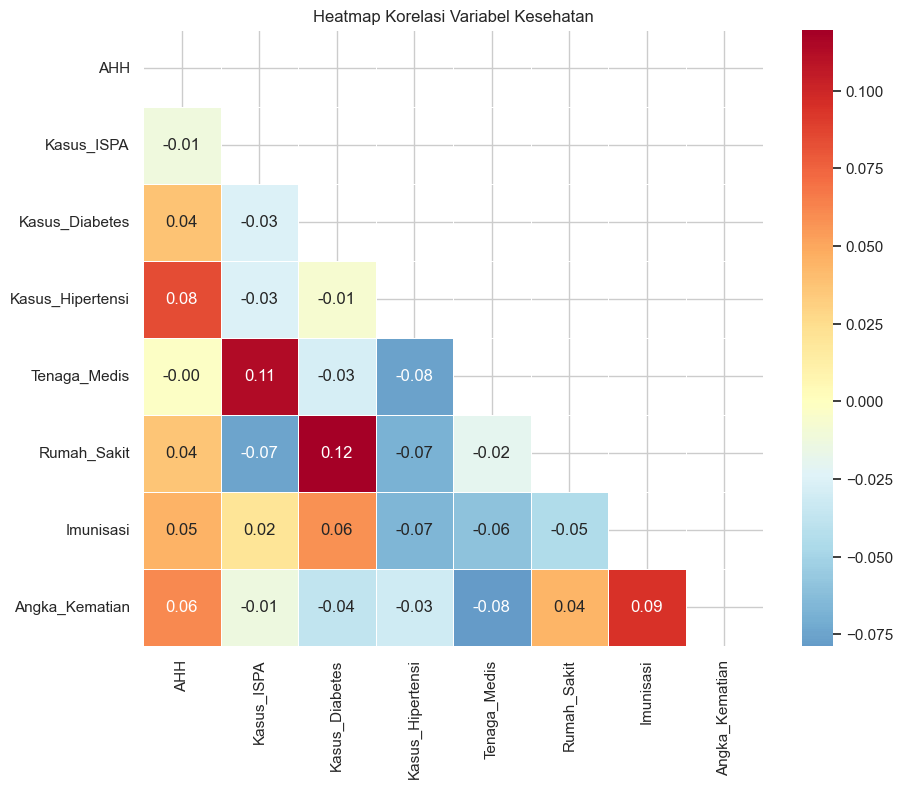

In [164]:
corr_cols = ['AHH', 'Kasus_ISPA', 'Kasus_Diabetes', 'Kasus_Hipertensi',
             'Tenaga_Medis', 'Rumah_Sakit', 'Imunisasi', 'Angka_Kematian']

# Catatan: Kolom 'Penduduk' tidak dimasukkan karena merupakan angka absolut,
# bukan per kapita. Penduduk akan berkorelasi tinggi dengan semua variabel kasus
# secara artifisial (provinsi berpenduduk besar menghasilkan angka absolut lebih tinggi).
# Untuk analisis bermakna, variabel kasus harus dinormalisasi per kapita terlebih dahulu.

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_clean[corr_cols].corr(), dtype=bool))
sns.heatmap(df_clean[corr_cols].corr(), mask=mask, annot=True, cmap='RdYlBu_r',
            center=0, fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Kesehatan')
plt.show()

---
## Ringkasan

| Tahap | Hasil |
|-------|-------|
| **Missing Values** | 22 (AHH) + 20 (Imunisasi) - diisi median per provinsi |
| **Outlier** | Ditangani dengan Winsorization (IQR 1.5x), kecuali kolom Penduduk |
| **Normalisasi** | 3 teknik: Min-Max, Z-Score, Log Transform |
| **Output** | `data/Dataset_kesehatan_cleaned.xlsx`, `data/Dataset_kesehatan_normalized.xlsx` |

### Insight Utama:
1. **Tenaga Medis** berkorelasi negatif lemah dengan **Angka Kematian**, tapi tidak selalu konsisten per provinsi.
2. Provinsi **tidak efisien** = memiliki tenaga medis di atas median tapi angka kematian juga di atas median.
3. Dari 3 penyakit yang tersedia, **Kasus_ISPA** memiliki korelasi tertinggi dengan angka kematian.
4. **Imunisasi** menunjukkan korelasi positif lemah dengan **AHH** - ada pengaruh, tapi ada banyak faktor lain.
5. **3 anomali** teridentifikasi: kasus ISPA ekstrem, perbedaan AHH antar provinsi, dan lonjakan kasus diabetes/hipertensi.